# Ensemble Learning || Gradient Boosting - Classifiaction
- Gradient Boosting is an ensemble method that builds models one at a time, where each new model tries to correct the errors made by the previous ones. It's called "gradient" because it uses a technique from math (gradient descent) to minimize errors step by step.
- STEP 1
  - Start simple : Make a basic prediction for everyone (e.g., the most common class).
- STEP 2
  - Find errors : Calculate how wrong the prediction was for each sample (residuals).
- STEP 3
  - Fit a tree : Train a small decision tree to predict those errors.
- STEP 4
  - Update & repeat : Add the tree's correction (scaled by learning rate), then repeat steps 2–4.

### Import Libraries 

In [79]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

### Load & Explore the Dataset
- Use the Breast Cancer Wisconsin dataset — a classic binary classification problem. 
- The goal is to predict whether a tumor is malignant (harmful) or benign (harmless) based on 30 features from cell images.

In [81]:
# ── Load the breast cancer dataset 
data = load_breast_cancer()

# Put it in a DataFrame for easy viewing
# 0 = malignant, 1 = benign
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target 
df.head(4)
  

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0


### Dataset Overview

Dataset Shape ::  (569, 31)

Null Values per Column :: 
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64 



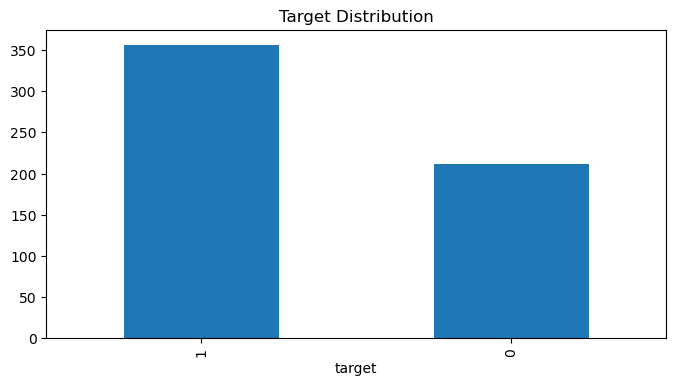

In [83]:
print("Dataset Shape :: ",df.shape)        
print("\nNull Values per Column :: ")
print(df.isnull().sum(),"\n")
plt.figure(figsize=(8,4))
df['target'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.show()

### Separate features (X) and target (y) 


In [85]:
# ── Separate features (X) and target (y) 
X = data.data       
y = data.target   

### Split & Scale the Data
- Split data into training (80%) and testing (20%) sets. 
- Gradient Boosting doesn't strictly require scaling, but it helps when combined with other models in a pipeline.

In [87]:
# ── Train/Test Split 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% for testing
    random_state=42,     # for reproducibility
    stratify=y           # keep class proportions equal in both splits
)

print(f"Train: {X_train.shape[0]} samples")   
print(f"Test:  {X_test.shape[0]} samples")    

# ── Feature Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit on train, transform train
X_test_scaled  = scaler.transform(X_test)       # only transform test (no fitting!)

Train: 455 samples
Test:  114 samples


###  Build the Model

In [89]:
# ── Create the Gradient Boosting Classifier 
gb_model = GradientBoostingClassifier(
    n_estimators=100,      # number of trees to build (more = better, but slower)
    learning_rate=0.1,     # how much each tree contributes (smaller = safer)
    max_depth=3,           # how deep each tree grows (shallow = less overfit)
    subsample=1.0,         # % of training data used per tree (1.0 = all data)
    min_samples_split=2,   
    min_samples_leaf=1,    # min samples that must remain in each leaf
    random_state=42       
)

# ── Train (fit) the model 
gb_model.fit(X_train_scaled, y_train)

GradientBoostingClassifier(random_state=42)

### Predict & Evaluate


Accuracy: 0.9561
ROC-AUC Score: 0.9907

               precision    recall  f1-score   support

   Malignant       0.97      0.90      0.94        42
      Benign       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



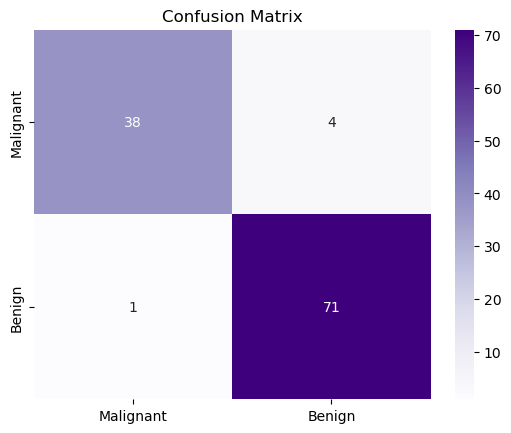

In [91]:
# ── Make Predictions 
y_pred       = gb_model.predict(X_test_scaled)   
y_pred_proba = gb_model.predict_proba(X_test_scaled)    

# ── Accuracy 
acc = accuracy_score(y_test, y_pred)
print(f"\nAccuracy: {acc:.4f}")

# ── ROC-AUC Score 
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"ROC-AUC Score: {roc_auc:.4f}")

# ── Full Classification Report 
print("\n",classification_report(
    y_test, y_pred,
    target_names=['Malignant', 'Benign']
))

# ── Confusion Matrix 
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Malignant', 'Benign'],
            yticklabels=['Malignant', 'Benign'])
plt.title('Confusion Matrix')
plt.show()

### Feature Importance

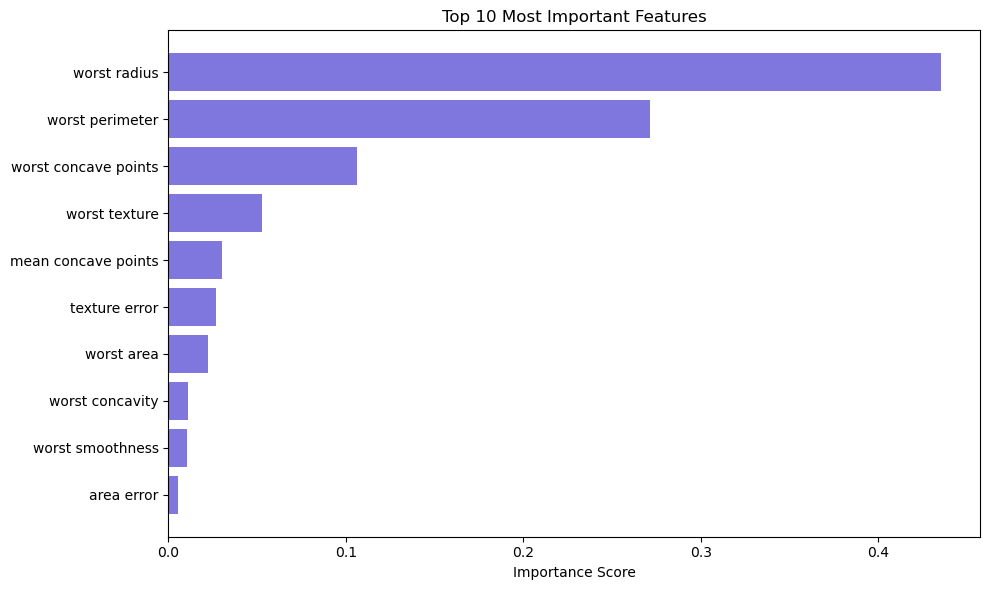

In [93]:
# ── Get Feature Importances
importances = gb_model.feature_importances_
feature_names = data.feature_names

# Sort from highest to lowest importance
indices = np.argsort(importances)[::-1]

# ── Plot Top 10 Features 
plt.figure(figsize=(10, 6))
plt.barh(
    [feature_names[i] for i in indices[:10]][::-1],
    [importances[i]   for i in indices[:10]][::-1],
    color='#7F77DD'
)
plt.xlabel('Importance Score')
plt.title('Top 10 Most Important Features')
plt.tight_layout()
plt.show()

### Hyperparameter Tuning with GridSearchCV

In [95]:
from sklearn.model_selection import GridSearchCV

# ── Define the parameter grid
param_grid = {
    'n_estimators'  : [50, 100, 200],      # try 3 options
    'learning_rate' : [0.05, 0.1, 0.2],   # try 3 options
    'max_depth'     : [2, 3, 4],            # try 3 options
}
# Total combinations: 3 × 3 × 3 = 27 combinations tested!

# ── Run Grid Search 
grid_search = GridSearchCV(
    estimator  = GradientBoostingClassifier(random_state=42),
    param_grid = param_grid,
    cv         = 5,          # 5-fold cross-validation
    scoring    = 'accuracy',
    n_jobs     = -1,         # use all CPU cores
    verbose    = 1
)

grid_search.fit(X_train_scaled, y_train)

# ── Best Parameters Found 
print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

# ── Use the Best Model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_scaled)
print("Test Accuracy (tuned):", accuracy_score(y_test, y_pred_best))

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best Parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 200}
Best CV Accuracy: 0.9714285714285715
Test Accuracy (tuned): 0.9473684210526315


### Cross-Validation
- Cross-validation tests the model multiple times on different parts of the data, giving a more reliable accuracy estimate than a single test split.

In [97]:
# ── 5-Fold Cross Validation 
cv_scores = cross_val_score(
    gb_model,
    X_train_scaled, y_train,
    cv=5,               # split data into 5 parts, test on each
    scoring='accuracy'
)

print("CV Scores:", cv_scores.round(4))
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Std Deviation: {cv_scores.std():.4f}")

CV Scores: [0.967  0.967  0.9451 0.9451 0.967 ]
Mean Accuracy: 0.9582
Std Deviation: 0.0108
